In [1]:
import math
import matplotlib.pyplot as plt
import numpy as np

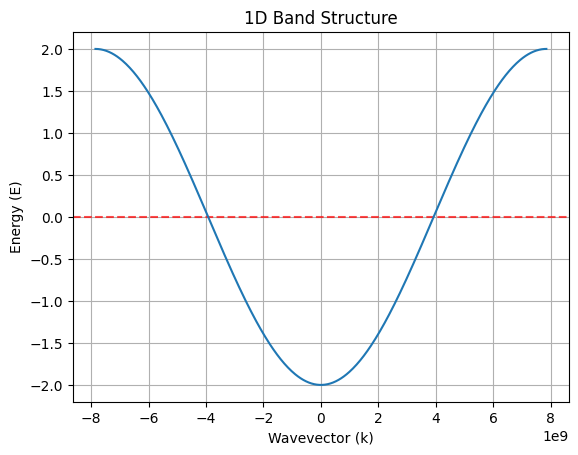

In [23]:
def band_structure(E0, t, a):  # Main function
    """It's a docstring describing what the function does"""
    
    def E(k):  # Subfunction
        return E0 - 2 * t * math.cos(k * a)
    # --- END of subfunction E(k) ---
    
    # 1. Define Brillouin zone limits [-pi/a to pi/a]
    k_max = math.pi / a  
    k_vals = np.linspace(-k_max, k_max, 500)  # Corrected range and comma
    
    # 2. Calculate energy for every k value using our subfunction E(k)
    energy = [E(k) for k in k_vals]  # Fixed lowercase k
    
    # 3. Plot the results
    plt.axhline(E0, color='red', linestyle='--', alpha=0.7, label=rf'On-site Energy $E_0 = {E0}$')
    plt.plot(k_vals, energy)
    plt.title("1D Band Structure")  # Added title text
    plt.xlabel("Wavevector (k)")
    plt.ylabel("Energy (E)")
    #plt.legend(loc='upper right')
    plt.grid(True)
    plt.show()

# Run the function
band_structure(E0=0.0, t=1.0, a=4e-10)

In [24]:
def draw_band_structure():
    # 1. Physics Parameters
    E0 = 0.0  # On-site energy
    t = 1.0  # Hopping integral
    a = 1.0  # Lattice constant

    # Nested helper function
    def E(k):
        return E0 - 2 * t * math.cos(k * a)

    # 2. Generate 20 wavevector (k) points across [-pi to +pi]
    k_min = -math.pi
    k_max = math.pi
    num_points = 21

    # Simple step size calculation
    step = (k_max - k_min) / (num_points - 1)

    # 3. Calculate all energy points in a list
    k_list = [k_min + i * step for i in range(num_points)]
    energy_list = [E(k) for k in k_list]

    # 4. Print text-based plot right in the terminal
    print("\n--- 1D BAND STRUCTURE (ASCII ART) ---")
    print("Energy (E)  |  Dispersion Curve")
    print("-" * 45)

    for k, energy in zip(k_list, energy_list):
        # Scale energy into spaces to draw the curve visually
        # Energy ranges from -2.0 to +2.0, so shift and scale it
        spaces = int((energy + 2.0) * 8)
        bar = " " * spaces + "*"

        print(f"E = {energy:5.2f} eV | {bar}")


# Run it!
draw_band_structure()


--- 1D BAND STRUCTURE (ASCII ART) ---
Energy (E)  |  Dispersion Curve
---------------------------------------------
E =  2.00 eV |                                 *
E =  1.90 eV |                                *
E =  1.62 eV |                             *
E =  1.18 eV |                          *
E =  0.62 eV |                     *
E = -0.00 eV |                *
E = -0.62 eV |            *
E = -1.18 eV |       *
E = -1.62 eV |    *
E = -1.90 eV | *
E = -2.00 eV | *
E = -1.90 eV | *
E = -1.62 eV |    *
E = -1.18 eV |       *
E = -0.62 eV |            *
E = -0.00 eV |                *
E =  0.62 eV |                     *
E =  1.18 eV |                          *
E =  1.62 eV |                             *
E =  1.90 eV |                                *
E =  2.00 eV |                                 *


In [26]:
import math

def calculate_effective_mass(t, a):
    # Reduced Planck's constant in eV*s (energy units matching t)
    hbar = 6.582e-16  
    
    # Formula: m* = hbar^2 / (2 * t * a^2)
    m_eff = (hbar**2) / (2 * t * (a**2))
    
    # Standard electron mass in kg (for comparison)
    m_0 = 9.109e-31  
    
    # Return as a fraction of free electron mass (m* / m_0)
    # Note: Convert hbar to Joules (1.054e-34) if comparing to SI mass m_0
    hbar_SI = 1.054e-34
    t_Joules = t * 1.602e-19
    m_eff_kg = (hbar_SI**2) / (2 * t_Joules * (a**2))
    
    return m_eff_kg / m_0

# Run for t = 1.5 eV, a = 4 Angstroms (4e-10 m)
ratio = calculate_effective_mass(t=1.5, a=4e-10)
print(f"Effective Mass m* = {ratio:.3f} * m_0")

Effective Mass m* = 0.159 * m_0


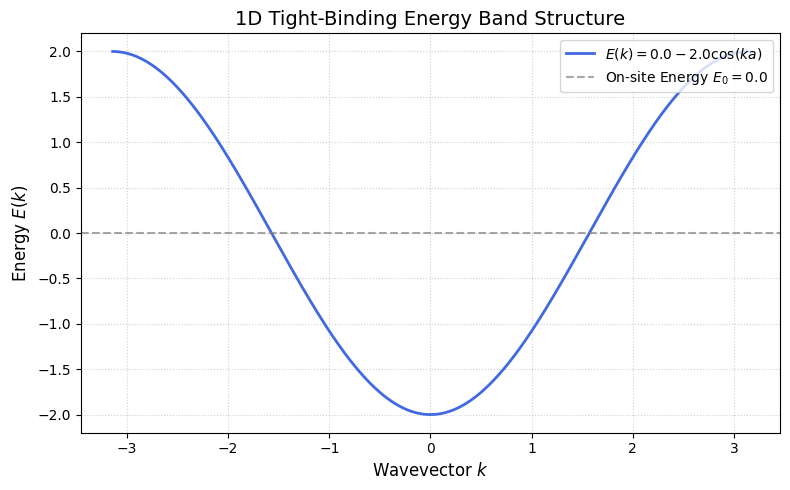

In [4]:
import numpy as np
import matplotlib.pyplot as plt

def plot_band(E0, t, a):
    # Subfunction: Tight-binding dispersion relation E(k) = E0 - 2*t*cos(k*a)
    def E(k):
        return E0 - 2 * t * np.cos(k * a)

    # Generate wavevector k values across the First Brillouin Zone [-pi/a, pi/a]
    k_vals = np.linspace(-np.pi / a, np.pi / a, 500)
    E_vals = E(k_vals)

    # Plot the band structure
    plt.figure(figsize=(8, 5))
    plt.plot(k_vals, E_vals, label=rf'$E(k) = {E0} - {2*t}\cos(ka)$', color='royalblue', linewidth=2)
    
    # Visual enhancements
    plt.axhline(E0, color='gray', linestyle='--', alpha=0.7, label=rf'On-site Energy $E_0 = {E0}$')
    plt.title('1D Tight-Binding Energy Band Structure', fontsize=14)
    plt.xlabel(r'Wavevector $k$', fontsize=12)
    plt.ylabel(r'Energy $E(k)$', fontsize=12)
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.legend(loc='upper right')
    plt.tight_layout()
    plt.show()

# Execution with standard parameters:
# E0 = 0.0 eV (On-site energy)
# t  = 1.0 eV (Hopping integral)
# a  = 1.0 Å  (Lattice constant)
plot_band(E0=0.0, t=1.0, a=1.0)

<Figure size 640x480 with 0 Axes>

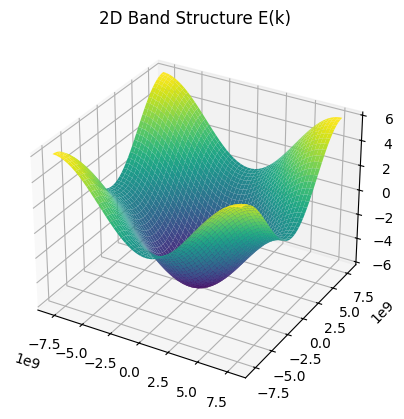

In [5]:
import math
import matplotlib.pyplot as plt


def plot_band_2d(E0, t, a):
  # Function for 2D Tight-Binding: E(kx, ky)
  def E(kx, ky):
    return E0 - 2 * t * (math.cos(kx * a) + math.cos(ky * a))

  # Generate kx and ky points from -pi/a to pi/a
  k_max = math.pi / a
  k_vals = [-k_max + (i * (2 * k_max / 49)) for i in range(50)]

  # Create 2D mesh grid list
  KX = [[kx for kx in k_vals] for _ in k_vals]
  KY = [[ky for _ in k_vals] for ky in k_vals]

  # Calculate Energy matrix
  energy_matrix = [
      [E(kx, ky) for kx in k_vals] for ky in k_vals
  ]

  # Plot 3D surface
  fig = plt.figure()
    # Modern, clean, and flexible
  fig, ax = plt.subplots(subplot_kw={'projection': '3d'})
  #ax = fig.add_subplot(111, projection='3d')
  ax.plot_surface(
      plt.np.array(KX),
      plt.np.array(KY),
      plt.np.array(energy_matrix),
      cmap='viridis',
  )
  plt.title('2D Band Structure E(k)')
  plt.show()


# Run with E0 = 0.0 eV, t = 1.5 eV, a = 4e-10 meters
plot_band_2d(E0=0.0, t=1.5, a=4e-10)